# β-VAE results
Compare the quantitative reconstruction--regularization trade-off.

## Run training once (only if needed)
Skip the next cell when saved outputs already exist.

In [ ]:
!cd .. && python scripts/train.py && python scripts/build_report_assets.py

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
results=pd.read_csv('../outputs/results.csv'); history=pd.read_csv('../outputs/history.csv'); results.round(3)

,beta,reconstruction_bce,kl,elbo,knn_accuracy,diversity
0,0.5,137.981,7.434,141.698,0.772,5.732
1,1.0,140.275,6.134,146.410,0.743,6.025
2,4.0,143.569,4.374,161.064,0.771,6.089


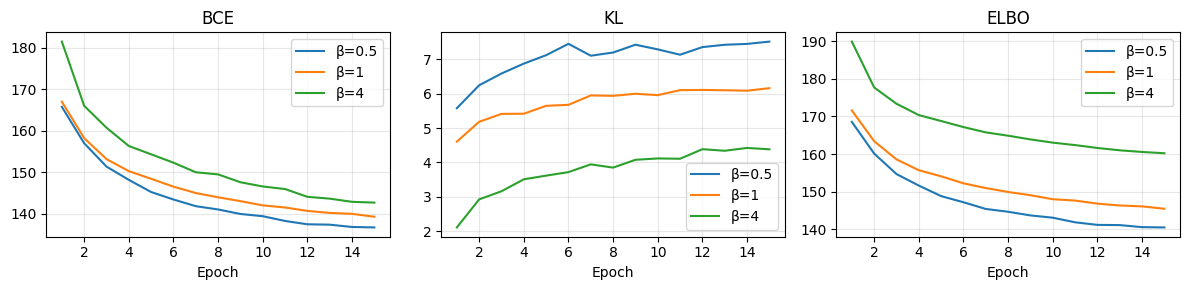

In [5]:
fig,axes=plt.subplots(1,3,figsize=(12,3))
for beta,g in history.groupby('beta'):
 axes[0].plot(g.epoch,g.validation_reconstruction_bce,label=f'β={beta:g}'); axes[1].plot(g.epoch,g.validation_kl,label=f'β={beta:g}'); axes[2].plot(g.epoch,g.validation_elbo,label=f'β={beta:g}')
for ax in axes: ax.legend(); ax.set_xlabel('Epoch'); ax.grid(alpha=.3)
axes[0].set_title('BCE'); axes[1].set_title('KL'); axes[2].set_title('ELBO'); fig.tight_layout()

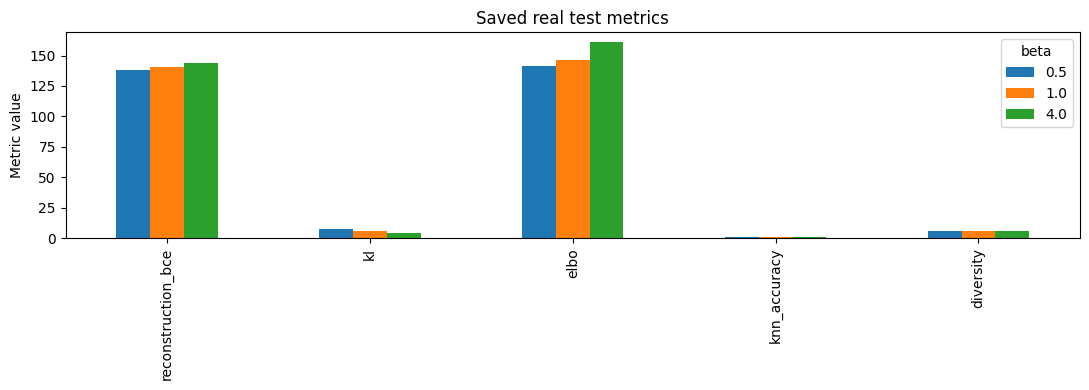

In [6]:
results.set_index('beta')[['reconstruction_bce','kl','elbo','knn_accuracy','diversity']].T.plot.bar(figsize=(11,4)); plt.ylabel('Metric value'); plt.title('Saved real test metrics'); plt.tight_layout()